In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

**Root Data Directory Path**

In [3]:
data_dir = r"C:\Users\Jatin Dhiman\PycharmProjects\signatureRecognition\notebook\data"

#### Total number of classes

In [4]:
class_name = os.listdir(data_dir)
len(class_name)

2

In [5]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T,datasets

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: {}".format(device))

Device: cpu


#### Transforming the data 

In [7]:
data_transform = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize(size=(224, 224)),
    T.RandomRotation(degrees=(-5, +5)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])

In [8]:
data = datasets.ImageFolder(data_dir, transform=data_transform)
total_count = len(data)

In [9]:
total_count

2640

In [10]:
print(data.class_to_idx)

{'Forged': 0, 'Original': 1}


#### Splitting the data

In [11]:
train_count = int(0.7 * total_count)
valid_count = int(0.2 * total_count)
test_count = total_count - train_count - valid_count
train_data, val_data, test_data = torch.utils.data.random_split(data, (train_count, valid_count, test_count))

In [12]:
len(train_data.indices)

1847

In [13]:
len(test_data.indices)

265

In [14]:
len(val_data.indices)

528

In [15]:
def show_image(image, label, get_denormalize=True):

    image = image.permute(1, 2, 0)

    mean = torch.FloatTensor([0.5])
    std = torch.FloatTensor([0.5])

    if get_denormalize:
        image = image * std + mean
        image = np.clip(image, 0, 1)

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(label)
    plt.axis("off")


def accuracy(y_pred, y_true):

    y_pred = F.softmax(y_pred, dim=1)

    top_p, top_class = y_pred.topk(
        1,
        dim=1
    )

    equals = top_class == y_true.view(
        *top_class.shape
    )

    return torch.mean(
        equals.type(torch.FloatTensor)
    )

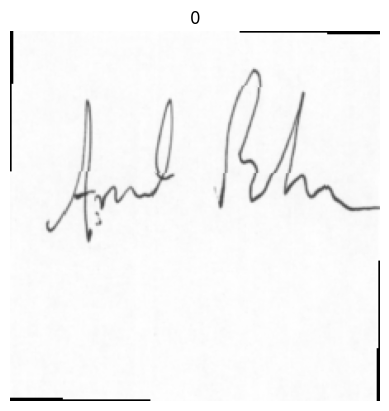

In [16]:
img, label = train_data[3]
show_image(img, label)

#### Data Loaders

In [19]:
trainloader = DataLoader(
    train_data,
    batch_size=16,
    shuffle=True
)

print(f"No. of batches in trainloader: {len(trainloader)}")
print(f"No. of Total examples: {len(trainloader.dataset)}")


validationloader = DataLoader(
    val_data,
    batch_size=16,
    shuffle=False
)

print(f"No. of batches in validationloader: {len(validationloader)}")
print(f"No. of Total examples: {len(validationloader.dataset)}")


testloader = DataLoader(
    test_data,
    batch_size=16,
    shuffle=False
)

print(f"No. of batches in testloader: {len(testloader)}")
print(f"No. of Total examples: {len(testloader.dataset)}")

No. of batches in trainloader: 116
No. of Total examples: 1847
No. of batches in validationloader: 33
No. of Total examples: 528
No. of batches in testloader: 17
No. of Total examples: 265


#### Model

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms

In [22]:
model = models.resnet34(
    weights=models.ResNet34_Weights.DEFAULT
)

# Change first convolution from 3 channels -> 1 channel
old_conv = model.conv1

model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

# Convert pretrained RGB weights to grayscale weights
model.conv1.weight.data = (
    old_conv.weight.data.mean(
        dim=1,
        keepdim=True
    )
)

In [23]:
# Replace classifier
model.fc = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(
        model.fc.in_features,
        len(class_name)
    )
)

model = model.to(device)

In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=1e-3,
    momentum=0.9
)

In [25]:
def train(
    model,
    criterion,
    optimizer,
    train_dataloader,
    validation_dataloader
):

    total_train_loss = 0
    total_validation_loss = 0

    # -------------------------
    # Training
    # -------------------------

    model.train()

    with tqdm(
        train_dataloader,
        unit="batch",
        leave=False
    ) as pbar:

        pbar.set_description("Training")

        for images, labels in pbar:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            output = model(images)

            loss = criterion(
                output,
                labels
            )

            loss.backward()

            optimizer.step()

            total_train_loss += loss.item()

    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    with torch.no_grad():

        with tqdm(
            validation_dataloader,
            unit="batch",
            leave=False
        ) as pbar:

            pbar.set_description("Validation")

            for images, labels in pbar:

                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )

                output = model(images)

                loss = criterion(
                    output,
                    labels
                )

                total_validation_loss += loss.item()

    # -------------------------
    # Average Loss
    # -------------------------

    train_loss = (
        total_train_loss /
        len(train_dataloader)
    )

    validation_loss = (
        total_validation_loss /
        len(validation_dataloader)
    )

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f}"
    )

    return train_loss, validation_loss

In [26]:
%%time

epochs = 5

for epoch in range(epochs):

    print(
        f"\nEpoch {epoch + 1}/{epochs}"
    )

    train(
        model,
        criterion,
        optimizer,
        trainloader,
        validationloader
    )


Epoch 1/5


Train loss: 0.1372 | Validation loss: 0.0025

Epoch 2/5


Train loss: 0.0187 | Validation loss: 0.0049

Epoch 3/5


Train loss: 0.0134 | Validation loss: 0.0100

Epoch 4/5


Train loss: 0.0042 | Validation loss: 0.0058

Epoch 5/5


Train loss: 0.0225 | Validation loss: 0.0079
CPU times: total: 3h 6min 12s
Wall time: 30min 58s


#### Model Saving

In [27]:
pwd

'C:\\Users\\Jatin Dhiman\\PycharmProjects\\signatureRecognition\\notebook'

In [28]:
Path = r'C:\\Users\\Jatin Dhiman\\PycharmProjects\\signatureRecognition\\notebook\\model.pt'
torch.save(model,Path)

#### Loading torch Model

In [29]:
model = torch.load(Path, weights_only=False)
model.eval()

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Model Evaluation

In [30]:
def evaluate(
    model,
    criterion,
    test_dataloader
):

    total_test_loss = 0

    model.eval()

    with torch.no_grad():

        with tqdm(
            test_dataloader,
            unit="batch",
            leave=False
        ) as pbar:

            pbar.set_description("Testing")

            for images, labels in pbar:

                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )

                output = model(images)

                loss = criterion(
                    output,
                    labels
                )

                total_test_loss += loss.item()

    test_loss = (
        total_test_loss /
        len(test_dataloader)
    )

    print(
        f"Test loss: {test_loss:.4f}"
    )

    return test_loss

In [31]:
evaluate(model,criterion,testloader)

Test loss: 0.0072


0.007174257997094709

#### Prediction

In [32]:
label_names = data.classes
label_names

['Forged', 'Original']

In [35]:
from PIL import Image

image = Image.open(
    r"C:\Users\Jatin Dhiman\PycharmProjects\signatureRecognition\notebook\data\Original\original_1_2.png"
).convert("RGB")


preprocess = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.Grayscale(
        num_output_channels=1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])


image = preprocess(image)

image = image.unsqueeze(0)

image = image.to(device)

In [36]:
model.eval()

with torch.no_grad():

    logits = model(image)

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    confidence, predicted_index = torch.max(
        probabilities,
        dim=1
    )


predicted_index = predicted_index.item()
confidence = confidence.item()

predicted_class_name = label_names[
    predicted_index
]

print(
    f"Predicted class: {predicted_class_name}"
)

print(
    f"Confidence: {confidence * 100:.2f}%"
)

Predicted class: Original
Confidence: 99.83%
